# Working with Langchain and LangGraph
- Models/Chatmodels
- Prompt Templates
- Parsers
- Tools


In [ ]:
!pip install langchain langchain_openai langchain_core langchain_community --quiet

OPENAI_API_VERSION="2025-04-01-preview"

In [2]:
# model
from langchain.chat_models import init_chat_model
model = init_chat_model("azure_openai:gpt-4o-mini")
output = model.invoke("Tell me a joke on laptop.")
print(output.content)

Why did the laptop break up with the smartphone?

Because it couldn't handle the constant notifications!


In [1]:
# prompt templates
from langchain_core.prompts import ChatPromptTemplate
prompt_temp = ChatPromptTemplate([("system","You are an expert translator, translate to {language}"),
                                  ("user","Translate: {text}")])
prompt_temp

PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


ChatPromptTemplate(input_variables=['language', 'text'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=['language'], input_types={}, partial_variables={}, template='You are an expert translator, translate to {language}'), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['text'], input_types={}, partial_variables={}, template='Translate: {text}'), additional_kwargs={})])

In [3]:
prompt_temp.invoke({"language":"hindi","text":"Hello Good Morning"})

ChatPromptValue(messages=[SystemMessage(content='You are an expert translator, translate to hindi', additional_kwargs={}, response_metadata={}), HumanMessage(content='Translate: Hello Good Morning', additional_kwargs={}, response_metadata={})])

In [4]:
from langchain_core.output_parsers import StrOutputParser
parser = StrOutputParser()

In [5]:
model.invoke(prompt_temp.invoke({"language":"hindi","text":"Hello Good Morning"}))

AIMessage(content='नमस्ते, शुभ प्रभात', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 25, 'total_tokens': 34, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_eb37e061ec', 'id': 'chatcmpl-DHkEAiXlqiMWcJFstqbP74qAS59MJ', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'filtered': False, 'detected': False}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}}}], 'finish_reason': 'stop', 'logprobs': None, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'protec

In [6]:
parser.invoke(model.invoke(prompt_temp.invoke({"language":"hindi","text":"Hello Good Morning"})))

'नमस्ते, शुभ प्रभात।'

In [7]:
# implementing a simple chain using LCEL
chain = prompt_temp | model | parser
chain.invoke({"language":"tamil","text":"Hello, Good Morning!"})


'வணக்கம், காலை வணக்கம்!'

## Static Workflow Design with LangGraph

In [8]:
# 1. Data model
from typing import TypedDict
# from pydantic import ..

class mystate(TypedDict):
    lang:str
    input_text:str
    answer:str

In [9]:
# node - translation node
def translation(state:mystate)->mystate:
    prompt_temp = ChatPromptTemplate([("system","You are an expert translator, translate to {language}"),
                                  ("user","Translate: {text}")])
    model = init_chat_model('azure_openai:gpt-4o-mini')
    parser = StrOutputParser()

    translation = prompt_temp | model | parser
    response = translation.invoke({"language":state['lang'],'text':state['input_text']})
    return {'answer':response}

In [ ]:
# create a graph
from langgraph.graph import StateGraph,START,END
graph_builder = StateGraph(mystate)
graph_builder.add_node('translation',translation)
graph_builder.add_edge(START,'translation')
graph_builder.add_edge('translation',END)

graph = graph_builder.compile()
graph

In [11]:
graph.invoke({"lang":'french','input_text':'How are you?'})

{'lang': 'french', 'input_text': 'How are you?', 'answer': 'Comment ça va ?'}

### Code Builder Workflow Agent

In [12]:
from typing import TypedDict
class myDataModel(TypedDict):
    task:str
    generated_code:str
    enhanced_code:str

In [21]:
# code generation node
def code_gen(state:myDataModel)->myDataModel:
    prompt_temp = ChatPromptTemplate([("system","You write python codes for any given task, technically accurate, concise"),
                                  ("user","Only provide code, not additional text. Task: {task}")])
    model = init_chat_model('azure_openai:gpt-4o-mini')
    parser = StrOutputParser()

    generator = prompt_temp | model | parser
    response = generator.invoke({"task":state['task']})
    return {'generated_code':response}
    

In [22]:
# code enhancer node
def code_enh(state:myDataModel)->myDataModel:
    prompt_temp = ChatPromptTemplate([("system","You enhance a provided python code, by adding docstring, comments and checking for syntacitc error."),
                                  ("user","Only provide enhanced code, Code: {code}")])
    model = init_chat_model('azure_openai:gpt-4o-mini')
    parser = StrOutputParser()

    enhancer = prompt_temp | model | parser
    response = enhancer.invoke({"code":state['generated_code']})
    return {'enhanced_code':response}
    

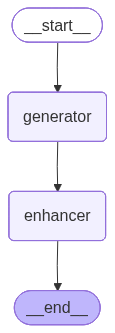

In [23]:
from langgraph.graph import StateGraph, START, END
builder = StateGraph(myDataModel)
builder.add_node("generator",code_gen)
builder.add_node('enhancer',code_enh)
builder.add_edge(START,'generator')
builder.add_edge('generator','enhancer')
builder.add_edge("enhancer",END)
graph = builder.compile()
graph

In [24]:
response = graph.invoke({"task":"fibonacci series"})
response

{'task': 'fibonacci series',
 'generated_code': '```python\ndef fibonacci(n):\n    fib_series = []\n    a, b = 0, 1\n    for _ in range(n):\n        fib_series.append(a)\n        a, b = b, a + b\n    return fib_series\n\n# Example usage\nn = 10\nprint(fibonacci(n))\n```',
 'enhanced_code': '```python\ndef fibonacci(n):\n    """\n    Generate a Fibonacci series of length n.\n\n    Parameters:\n    n (int): The length of the Fibonacci series to generate.\n\n    Returns:\n    list: A list containing the Fibonacci series of length n.\n    \n    Raises:\n    ValueError: If n is negative, as a Fibonacci series cannot have negative length.\n    """\n    if n < 0:\n        raise ValueError("The length of the Fibonacci series cannot be negative.")\n    \n    fib_series = []  # Initialize an empty list to store the Fibonacci series\n    a, b = 0, 1  # The first two Fibonacci numbers\n\n    for _ in range(n):\n        fib_series.append(a)  # Append the current Fibonacci number to the series\n    

In [25]:
print(response['enhanced_code'])

```python
def fibonacci(n):
    """
    Generate a Fibonacci series of length n.

    Parameters:
    n (int): The length of the Fibonacci series to generate.

    Returns:
    list: A list containing the Fibonacci series of length n.
    
    Raises:
    ValueError: If n is negative, as a Fibonacci series cannot have negative length.
    """
    if n < 0:
        raise ValueError("The length of the Fibonacci series cannot be negative.")
    
    fib_series = []  # Initialize an empty list to store the Fibonacci series
    a, b = 0, 1  # The first two Fibonacci numbers

    for _ in range(n):
        fib_series.append(a)  # Append the current Fibonacci number to the series
        a, b = b, a + b  # Update a and b to the next Fibonacci numbers

    return fib_series  # Return the complete Fibonacci series

# Example usage
n = 10  # Length of Fibonacci series
print(fibonacci(n))  # Output the Fibonacci series of length n
```


#### Understanding structured outputs from LLMs

In [29]:
review = """ the lapop I purchased is great, it is HP Envy x 360, 
i like it, bcs I can use is it as a tab sometimes, and it is small and sleek. easy to carry and long lasting. 
I purchased it from Delhi. I am travelling to Kuala Lumpur tomorrow. """

prompt_temp = ChatPromptTemplate([("user","Extract name of company, name of product and location of purchase, provide structured outptu for the review {review}")])

print(parser.invoke(model.invoke(prompt_temp.invoke({"review":review}))))

```json
{
  "company": "HP",
  "product": "Envy x 360",
  "location_of_purchase": "Delhi"
}
```


In [34]:
from pydantic import BaseModel, Field

class ner(BaseModel):
    manufacturer:str = Field(description = "name of company which produced the product")
    product_name:str = Field(description = "Name of Product")
    location:str = Field(description = "city where customer purchased it")


ner_model = model.with_structured_output(ner)
response = ner_model.invoke(prompt_temp.invoke({"review":review}))

c:\Users\labuser\Desktop\EY_GenAI_Architect\genai\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=ner(manufacturer='HP', pr... 360', location='Delhi'), input_type=ner])
  return self.__pydantic_serializer__.to_python(


In [35]:
response.manufacturer

'HP'

In [36]:
response.product_name

'Envy x 360'

In [37]:
response.location

'Delhi'